In [93]:
# [셀 1] 라이브러리 import
#
# ⚠️ 중요 전제 (반드시 읽을 것)
# - 본 노트북은 GDELT GKG(Global Knowledge Graph)를 사용
# - GDELT는 전세계 뉴스 수집 DB이며, 네이버 전용 데이터가 아님
# - 검색어는 혼합형(영문 + 한글)을 OR 조건으로 사용
#
#   ("KOSPI 5000" OR KOSPI AND 5000 OR "코스피 5000")
#
# - 한글 검색은 재현성이 떨어질 수 있음
# - 따라서 결과는 '정확한 기사 수'가 아니라
#   '시간에 따른 언급 강도의 근사치'로 해석해야 함

import pandas as pd
import requests
import io
import zipfile
import datetime as dt

import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


In [94]:
# [셀 2] 분석 기간 설정
# GDELT는 15분 단위 파일을 제공하므로
# 일별 집계를 위해 날짜 구간을 명시

START_DATE = "2025-09-01"
END_DATE   = "2026-01-31"

start_dt = pd.to_datetime(START_DATE)
end_dt   = pd.to_datetime(END_DATE)


In [95]:
# [셀 3] GDELT GKG 일별 파일 URL 생성
#
# GDELT GKG는 하루에 여러 파일(15분 단위)이 있음
# 파일명 예:
# 20240101000000.gkg.csv.zip

def generate_gkg_urls(start_dt, end_dt):
    base = "http://data.gdeltproject.org/gkg/"
    urls = []

    cur = start_dt
    while cur <= end_dt:
        date_str = cur.strftime("%Y%m%d")
        # 하루치 모든 15분 파일
        for hh in range(0, 24):
            for mm in ["00", "15", "30", "45"]:
                ts = f"{date_str}{hh:02d}{mm}00"
                urls.append(base + ts + ".gkg.csv.zip")
        cur += pd.Timedelta(days=1)

    return urls


In [96]:
# [셀 4] GKG 다운로드 후 키워드 필터링
#
# GKG 주요 컬럼:
# - DATE
# - Themes
# - Persons
# - Organizations
# - Locations
# - V2Themes
# - V2Tone
#
# 우리는 전체 텍스트 필드에서 키워드 포함 여부로 필터

SEARCH_TERMS = [
    "KOSPI 5000",
    "KOSPI",
    "코스피 5000"
]

def fetch_gkg_counts(urls, search_terms):
    rows = []

    for url in urls:
        try:
            r = requests.get(url, timeout=20)
            if r.status_code != 200:
                continue

            with zipfile.ZipFile(io.BytesIO(r.content)) as z:
                with z.open(z.namelist()[0]) as f:
                    df = pd.read_csv(
                        f,
                        sep="\t",
                        header=None,
                        dtype=str,
                        encoding="latin1",
                        low_memory=False
                    )

            # DATE 컬럼은 0번
            df["DATE"] = pd.to_datetime(df[0].str.slice(0, 8), format="%Y%m%d")

            # 모든 텍스트 컬럼을 하나로 합쳐 검색
            text_blob = df.astype(str).agg(" ".join, axis=1).str.upper()

            mask = False
            for term in search_terms:
                mask = mask | text_blob.str.contains(term.upper(), regex=False)

            matched = df.loc[mask]
            if not matched.empty:
                rows.append(
                    matched.groupby("DATE").size().reset_index(name="count")
                )

        except Exception:
            # GDELT 파일 일부는 없는 경우도 있음
            continue

    if not rows:
        return pd.DataFrame(columns=["DATE", "count"])

    out = pd.concat(rows)
    out = out.groupby("DATE")["count"].sum().reset_index()
    return out


In [97]:
# [셀 5] 실행 (시간 오래 걸림 – 정상)
# 이게 다 조사하는 버전인데 ^^ㅣ바 몇 개월만 해도 몇 시간 걸릴 예정이라 아래 간략한 버전으로 리메이크 함. 
# 이걸로 하고싶으면 아래 주석 처리 해제

#gkg_urls = generate_gkg_urls(start_dt, end_dt)
#df_news = fetch_gkg_counts(gkg_urls, SEARCH_TERMS)
#df_news.head()


In [98]:
import io
import requests
import pandas as pd

GDELT_DOC_ENDPOINT = "https://api.gdeltproject.org/api/v2/doc/doc"

def _to_gdelt_dt(s: str, end: bool = False) -> str:
    d = pd.to_datetime(s)
    return d.strftime("%Y%m%d") + ("235959" if end else "000000")

query = '("KOSPI 5000" OR "코스피 5000" OR KOSPI 5000 OR 코스피 5000)'

params = {
    "query": query,
    "mode": "timelinevolraw",
    "format": "csv",
    "startdatetime": _to_gdelt_dt(START_DATE, end=False),
    "enddatetime": _to_gdelt_dt(END_DATE, end=True),
}

r = requests.get(GDELT_DOC_ENDPOINT, params=params, timeout=90)

print("HTTP status:", r.status_code)
print("Content-Type:", r.headers.get("Content-Type"))
print("Requested URL (debug):", r.url)

r.raise_for_status()

text = (r.text or "").strip()

print("\n--- response head (first 300 chars) ---")
print(text[:300])
print("--- end ---\n")

# ✅ HTML이면 즉사 (0으로 덮지 않음)
ctype = (r.headers.get("Content-Type") or "").lower()
if "text/html" in ctype:
    raise RuntimeError(f"GDELT가 CSV가 아니라 HTML을 반환했소. head={text[:200]}")

# ✅ 여기서 df_raw를 '반드시' 만든다
df_raw = pd.read_csv(io.StringIO(text))
print("[ok] df_raw created:", df_raw.shape)
print(df_raw.head())


HTTP status: 200
Content-Type: text/csv; charset=utf-8
Requested URL (debug): https://api.gdeltproject.org/api/v2/doc/doc?query=%28%22KOSPI+5000%22+OR+%22%EC%BD%94%EC%8A%A4%ED%94%BC+5000%22+OR+KOSPI+5000+OR+%EC%BD%94%EC%8A%A4%ED%94%BC+5000%29&mode=timelinevolraw&format=csv&startdatetime=20250901000000&enddatetime=20260131235959

--- response head (first 300 chars) ---
﻿Date,Series,Value
2025-09-01,Article Count,189
2025-09-01,Total Monitored Articles,117273
2025-09-02,Article Count,229
2025-09-02,Total Monitored Articles,151577
2025-09-03,Article Count,153
2025-09-03,Total Monitored Articles,127947
2025-09-04,Article Count,318
2025-09-04,Total Monitored Articles,
--- end ---

[ok] df_raw created: (300, 3)
         Date                    Series   Value
0  2025-09-01             Article Count     189
1  2025-09-01  Total Monitored Articles  117273
2  2025-09-02             Article Count     229
3  2025-09-02  Total Monitored Articles  151577
4  2025-09-03             Article Count     1

In [99]:
# ===== #6번 셀 =====
import pandas as pd

# 방어
if df_raw is None:
    raise RuntimeError("df_raw가 None이오. #5번 셀을 먼저 실행하시오.")

df = df_raw.copy()
df.columns = [c.strip() for c in df.columns]

# Article Count만 필터
df["Series"] = df["Series"].astype(str).str.strip().str.lower()
df = df[df["Series"].eq("article count")].copy()

# Date / count 정리
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["count"] = pd.to_numeric(df["Value"], errors="coerce")

df = df.dropna(subset=["Date", "count"])
df = df.groupby("Date", as_index=False)["count"].sum()
df["count"] = df["count"].astype(int)

# 전체 기간 보강
full = _empty_daily_series(START_DATE, END_DATE, col="count")
full["Date"] = pd.to_datetime(full["Date"])

df_news = full.merge(df, on="Date", how="left")
df_news["count"] = df_news["count_y"].fillna(0).astype(int)
df_news = df_news[["Date", "count"]]

# 검증 출력 (이게 0 아니면 성공)
print("NEWS CHECK -> sum:", int(df_news["count"].sum()),
      "max:", int(df_news["count"].max()))
display(df_news.head())


NEWS CHECK -> sum: 33842 max: 426


,Date,count
0,2025-09-01,189
1,2025-09-02,229
2,2025-09-03,153
3,2025-09-04,318
4,2025-09-05,322


df_news check -> sum: 33842 max: 426


,Date,count
0,2025-09-01,189
1,2025-09-02,229
2,2025-09-03,153
3,2025-09-04,318
4,2025-09-05,322


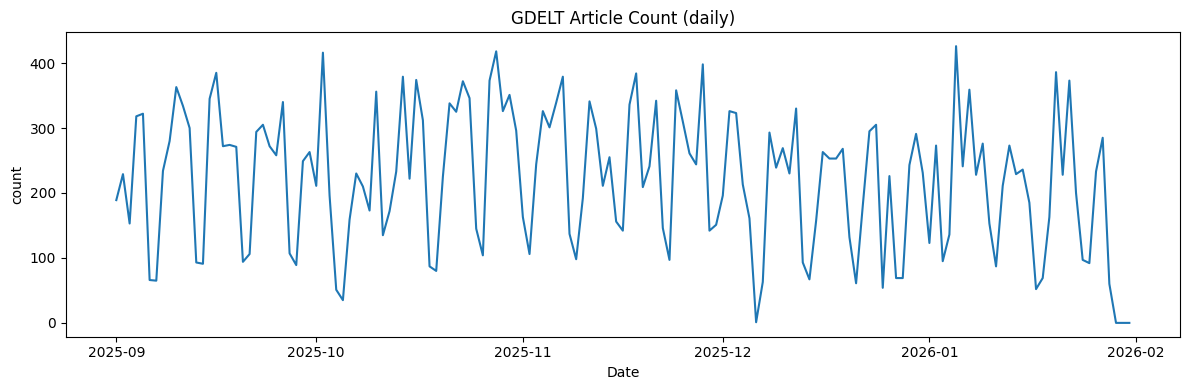

[]


In [100]:
# ===== #7번 셀: 뉴스 언급 그래프 (df_news 확정 사용) =====
import matplotlib.pyplot as plt

print("df_news check -> sum:", int(df_news["count"].sum()), "max:", int(df_news["count"].max()))
display(df_news.head())

plt.figure(figsize=(12,4))
plt.plot(df_news["Date"], df_news["count"])
plt.title("GDELT Article Count (daily)")
plt.xlabel("Date")
plt.ylabel("count")
plt.tight_layout()
plt.show()

print([name for name in globals().keys() if "price" in name.lower() or "close" in name.lower()])


In [107]:
#7.5
print("rows:", len(price_df))
print("Date dtype:", price_df["Date"].dtype)
print("Close NaN:", int(price_df["Close"].isna().sum()))
print("Close non-null:", int(price_df["Close"].notna().sum()))
print("duplicate dates:", int(price_df["Date"].duplicated().sum()))
display(price_df[price_df["Close"].isna()].head(10))


rows: 153
Date dtype: datetime64[us]
Close NaN: 54
Close non-null: 99
duplicate dates: 0


,Date,News_Count,Close,IsTradingDay,Close_FF,News_7D_MA
5,2025-09-06,0,NaN,False,3205.120117,0.0
6,2025-09-07,0,NaN,False,3205.120117,0.0
12,2025-09-13,0,NaN,False,3395.540039,0.0
13,2025-09-14,0,NaN,False,3395.540039,0.0
19,2025-09-20,0,NaN,False,3445.239990,0.0
20,2025-09-21,0,NaN,False,3445.239990,0.0
26,2025-09-27,0,NaN,False,3386.050049,0.0
27,2025-09-28,0,NaN,False,3386.050049,0.0
32,2025-10-03,0,NaN,False,3549.209961,0.0
33,2025-10-04,0,NaN,False,3549.209961,0.0


price_df candidates (top 10): [('df_final', 153), ('price_df', 153), ('df_kospi', 99), ('_12', 10), ('_23', 10), ('_11', 5), ('_22', 5), ('_57', 5)]
NEWS CHECK -> sum: 33842 max: 426


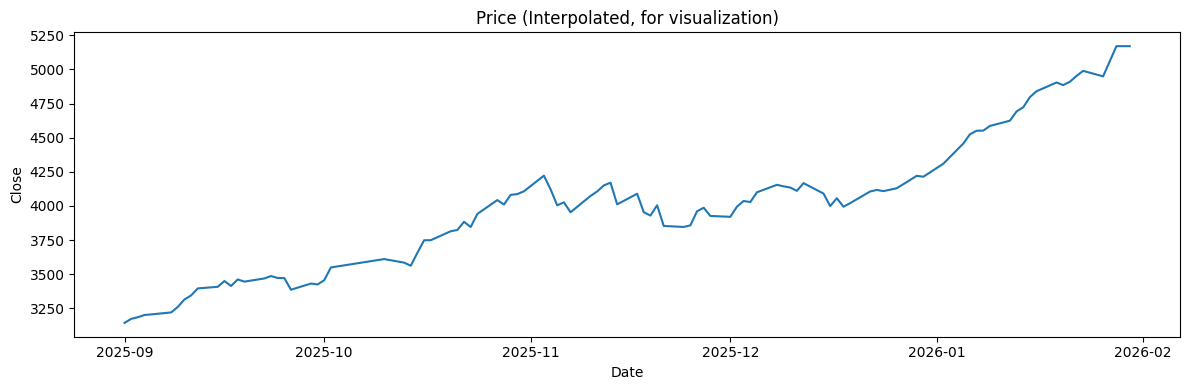

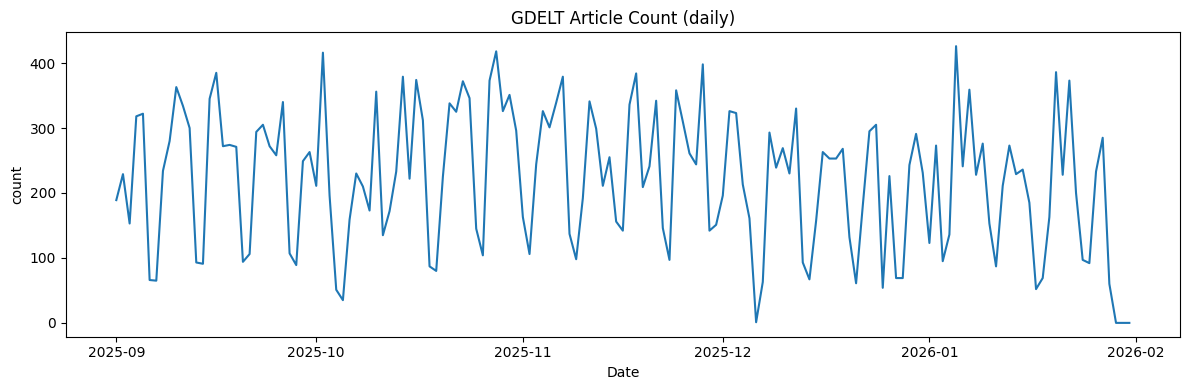

In [ ]:
# ===== #8번 셀: 그래프 2장(주가 / 뉴스) =====
import pandas as pd
import matplotlib.pyplot as plt

# 0) 주가 DF 자동 선택: (Date, Close) 있고, 행이 가장 많은 DF
g = list(globals().items())
cands = []
for k, v in g:
    if isinstance(v, pd.DataFrame):
        cols = set(map(str, v.columns))
        if {"Date", "Close"}.issubset(cols):
            cands.append((k, len(v)))

cands = sorted(cands, key=lambda x: x[1], reverse=True)
print("price_df candidates (top 10):", cands[:10])

if not cands:
    raise RuntimeError("Date/Close 컬럼 가진 주가 DF가 없소. 주가 만드는 셀을 먼저 실행하시오.")

price_name = cands[0][0]
price_df = globals()[price_name].copy()
price_df["Date"] = pd.to_datetime(price_df["Date"])
price_df = price_df.sort_values("Date")

# 1) 뉴스 DF 정리
news_df = df_news.copy()
news_df["Date"] = pd.to_datetime(news_df["Date"])
news_df = news_df.sort_values("Date")

print("NEWS CHECK -> sum:", int(news_df["count"].sum()), "max:", int(news_df["count"].max()))

plt.close("all")

# (A) 주가 그래프
#선형 보간버전임  
p = price_df[["Date","Close"]].copy()
p = p.sort_values("Date").set_index("Date")

# 영업일 기준으로 리인덱스 → 보간
idx = pd.date_range(p.index.min(), p.index.max(), freq="B")
p = p.reindex(idx)
p["Close"] = p["Close"].interpolate(method="time")

plt.figure(figsize=(12,4))
plt.plot(p.index, p["Close"])
plt.title("Price (Interpolated, for visualization)")
plt.xlabel("Date")
plt.ylabel("Close")
plt.tight_layout()
plt.show()


# (B) 뉴스 그래프
plt.figure(figsize=(12,4))
plt.plot(news_df["Date"].values, news_df["count"].values)
plt.title("GDELT Article Count (daily)")
plt.xlabel("Date")
plt.ylabel("count")
plt.tight_layout()
plt.show()


In [103]:
# [셀 9] 기사 샘플 확인 (진짜로 뉴스가 들어왔는지 검증)

df_news_items[["pubDate","title","originallink"]].head(20)


,pubDate,title,originallink
0,2026-01-28,<b>코스피 5000</b> 돌파에 ‘공포지수’ 역대급 상승…너무 올라서? 더 오를...,https://www.ekn.kr/web/view.php?key=2026012802...
1,2026-01-28,"하나자산, '<b>코스피 5000</b> 시대' 1Q 200 액티브 ETF 기자간담...",http://www.newslock.co.kr/news/articleView.htm...
2,2026-01-28,"삼성자산, 'KODEX 200' 전체 ETF 순자산 1위 등극",http://www.newslock.co.kr/news/articleView.htm...
3,2026-01-28,"[N2 특징주] 삼성전자, 역대 최고가 기록하며 '16만전자' 달성",https://www.news2day.co.kr/article/20260128500118
4,2026-01-28,"삼성자산운용, 'KODEX 200' 순자산 14.4조원 기록",http://www.enewstoday.co.kr/news/articleView.h...
5,2026-01-28,"삼성자산운용 KODEX 200 ETF, 'TIGER 미국S&amp;P500' 따돌리...",https://www.g-enews.com/view.php?ud=2026012809...
6,2026-01-28,"&quot;<b>코스피 5000</b> 시대 진단&quot; 대신증권, 중장기 증시...",http://www.economytalk.kr/news/articleView.htm...
7,2026-01-28,"삼성운용, 'KODEX 200 ETF' 순자산 14.4조원…전체 ETF 순자산 1위 기록",https://www.onews.tv/news/articleView.html?idx...
8,2026-01-28,"한준호 “지선 앞두고 합당, 정청래 행위 자체가 다른 의도 있다는 의심...",https://www.donga.com/news/Politics/article/al...
9,2026-01-28,"형님따라 아우도… 4년 만에 천스닥, '삼천닥' 가려면 [<b>코스피</b> 5천]",https://it.chosun.com/news/articleView.html?id...
